In [1]:
import mcstasscript as ms
import LET_functions
from scippneutron.conversion.graph.beamline import beamline
from scippneutron.conversion.graph.tof import elastic

In [2]:
def run(union_detector=True, order=None, air=False):
    
    instrument = LET_functions.make_instrument(union_detector=union_detector, order=order, air=air)
    
    sample = instrument.add_component("sample", "Union_cylinder", after="sample_position")
    sample.set_parameters(radius=0.01, yheight=0.03, priority=1000, material_string='"Fe"')
    sample.set_AT(0, RELATIVE="sample_position")
    
    beamstop = instrument.add_component("beamstop", "Union_cylinder", after="sample_position")
    beamstop.set_parameters(radius=0.03, yheight=0.03, priority=1001, material_string='"Cd"', p_interact=0.1)
    beamstop.set_AT(0.4, RELATIVE="sample_position")
    beamstop.set_ROTATED([90, 0, 0], RELATIVE="sample_position")

    instrument.settings(ncount=1E6, mpi=10, suppress_output=True)

    instrument.set_parameters(E0=15, dE=12)
    
    data = instrument.backengine()

    source_dist = -instrument.get_component("source").dist
    da = LET_functions.extract(data, union_detector=union_detector, source_dist=source_dist)

    # McStas provides absolute time, not time of flight
    da.coords["tof"] = da.coords["t"]
    
    graph = {**beamline(scatter=True), **elastic("tof")}
    
    da = da.transform_coords("energy", graph=graph)
    da = da.transform_coords("wavelength", graph=graph)
    da = da.transform_coords("dspacing", graph=graph)

    return da

### Compare Union and perfect detector

In [3]:
scattering_order = None
air=False

da = run(union_detector=True, order=scattering_order, air=False)
da_perfect = run(union_detector=False, order=scattering_order, air=False)

The following components are found in the work directory / input_path:
     Union_abs_logger_nD.comp
These definitions will be used instead of the installed versions.
The following components are found in the work directory / input_path:
     Union_abs_logger_nD.comp
These definitions will be used instead of the installed versions.
McStasDataEvent: detector with 212740 events. Variables: p th x y z t n


<scipp.Variable> (dspacing: 600)    float64             [Å]  [0.1, 0.104007, ..., 2.49599, 2.5]


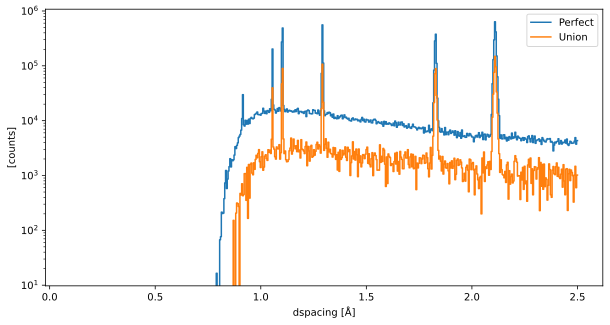

In [5]:
import scipp as sc
import plopp as pp
%matplotlib inline

d_bins = sc.linspace("dspacing", start=0.1, stop=2.5, num=600, unit="Å")
print(d_bins)
da.hist(dspacing=d_bins).plot(norm="linear", figsize=(10,10))

pp.plot({"Perfect": da_perfect.hist(dspacing=d_bins),
         "Union": da.hist(dspacing=d_bins)
        }, figsize=(10,5), norm="log")

In [ ]:
da = run(union_detector=True, order=None)
da_perfect = run(union_detector=True, order=1)

In [ ]:
import scipp as sc
import plopp as pp
%matplotlib inline

d_bins = sc.linspace("dspacing", start=0.1, stop=2.5, num=600, unit="Å")
print(d_bins)
da.hist(dspacing=d_bins).plot(norm="linear", figsize=(10,10))

pp.plot({"Union 1 scattering": da_perfect.hist(dspacing=d_bins),
         "Union with multiple": da.hist(dspacing=d_bins)
        }, figsize=(10,5))